# 05 · Análisis de Negocio — gaps, cursos e insights trazables

**Objetivo del TFG:** traducir los resultados analíticos en **insights de negocio accionables**, cada uno
**trazado a un objetivo (OE)** y al **modelo** que lo soporta, y apoyado en lo que *de verdad* salió.

**Qué hace este notebook**
1. **Gap analysis oferta–demanda** a nivel de *pool*, con **corrección de idioma** (ES↔EN) para no
   inflar gaps falsos de soft skills.
2. Conecta cada **gap real** con **cursos REALES del catálogo** (citados por nombre y URL), con matching
   por **palabra completa** (sin falsos positivos).
3. **Matriz de trazabilidad** insight → OE → modelo → evidencia, con recomendaciones.

**Entradas:** `data/clean/*.csv`, `data/matchkey/courses.csv`,
`data/clean/model1_representaciones_comparativa.csv`, `data/clean/model2_ranking_comparison.csv`.
**Salidas:** `data/clean/skill_gap_analysis.csv`, `data/clean/gap_to_courses.csv` + figura.

> **Honestidad (CLAUDE.md):** NO se inventan segmentos/personas de candidatos — el Modelo 1 mostró
> que **no hay segmentación fuerte** (talento homogéneo), así que el análisis es a nivel de *pool*.

## 0. Objetivos del TFG (OE) y mapa a modelos

Redacción **literal del anteproyecto** y notebook/modelo que responde a cada uno:

| OE | Objetivo (anteproyecto) | Responde |
|----|-------------------------|----------|
| **OE1** | Cuantificar el desajuste entre las competencias que ofrecen los candidatos y las que demandan las vacantes, identificando qué competencias concretas presentan mayor brecha. | **05 · Gap analysis** |
| **OE2** | Evaluar si un enfoque de recuperación de información (TF-IDF y similitud del coseno) aporta valor sobre el sistema de matching heurístico vigente, y precisar en qué aspecto lo hace. | **03 · Modelo 2** |
| **OE3** | Determinar si las categorías de vacante disponibles permiten segmentar adecuadamente la oferta de empleo, o si se requiere un enfoque alternativo de clasificación. | **04 · Modelo 3** |
| **OE4** | Evaluar el grado de diferenciación entre los perfiles de los candidatos, para valorar la viabilidad de un emparejamiento de perfiles complementarios (co-teaching). | **02 · Modelo 1** |
| **OE5** | Identificar oportunidades concretas de cierre de la brecha de competencias mediante recomendación de formación, conectando cada carencia con un recurso formativo real. | **05 · Gap→cursos** |

*(El notebook **01 · Ingeniería del Dato** es transversal: prepara y audita los datos que usan todos los OE.)*

In [1]:
import re, unicodedata, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
ACCENT = "#A100FF"

def find_repo_root(start: Path) -> Path:
    p = start.resolve()
    for _ in range(8):
        if (p / "data" / "clean").exists() or (p / "CLAUDE.md").exists():
            return p
        p = p.parent
    return start.resolve()

def strip_accents(s: str) -> str:
    s = unicodedata.normalize("NFKD", str(s))
    return "".join(c for c in s if not unicodedata.combining(c)).lower().strip()

REPO_ROOT = find_repo_root(Path.cwd())
CLEAN = REPO_ROOT / "data" / "clean"
MK = REPO_ROOT / "data" / "matchkey"
FIG = REPO_ROOT / "notebooks" / "figures"; FIG.mkdir(parents=True, exist_ok=True)
print("REPO_ROOT:", REPO_ROOT)

REPO_ROOT: C:\Users\miguel.e.fernandez\Desktop\MatchKey-GenAI-Maverick


## 1. Gap analysis oferta–demanda (nivel pool, con corrección de idioma) — OE1

- **Demanda** = % de vacantes que piden cada skill (`importance ∈ {must, nice, tech_stack, soft_skill}`).
- **Oferta** = % de candidatos que tienen cada skill.
- **Corrección de idioma:** las soft skills de los candidatos están en **español** y las de las vacantes en
  **inglés**. Sin corregir, `collaboration`/`communication` aparecerían como gaps enormes siendo falsos
  (el candidato tiene `trabajo en equipo`/`comunicación`). Aplicamos un mapeo ES↔EN para la **oferta ajustada**.

In [2]:
cs = pd.read_csv(CLEAN / "candidate_skills_clean.csv")
js = pd.read_csv(CLEAN / "job_skills_clean.csv")
N_CAND = cs["candidate_id"].nunique()
N_JOBS = pd.read_csv(CLEAN / "vacantes_clean.csv")["job_id"].nunique()

# Oferta: nº de candidatos por skill (clave sin acentos para cruzar idiomas)
cs["k"] = cs["skill_norm"].map(strip_accents)
supply_cnt = cs.groupby("k")["candidate_id"].nunique()
supply_pct_by_k = (supply_cnt / N_CAND * 100)

# Demanda: nº de vacantes por skill
DEMAND_IMP = {"must", "nice", "tech_stack", "soft_skill"}
jd = js[js["importance"].isin(DEMAND_IMP)].copy()
jd["k"] = jd["skill_norm"].map(strip_accents)
demand_cnt = jd.groupby("k")["job_id"].nunique()

# Mapeo ES<->EN de soft skills (oferta ajustada). Claves EN -> equivalentes ES del candidato.
SOFT_EN_ES = {
    "collaboration": ["trabajo en equipo", "colaboracion"],
    "teamwork": ["trabajo en equipo"],
    "communication": ["comunicacion"],
    "problem solving": ["resolucion de problemas"],
    "problem-solving": ["resolucion de problemas"],
    "adaptability": ["adaptabilidad"],
    "flexibility": ["adaptabilidad", "flexibilidad"],
    "leadership": ["liderazgo"],
    "critical thinking": ["pensamiento critico"],
    "time management": ["gestion del tiempo"],
    "proactivity": ["proactividad"],
    "attention to detail": ["atencion al detalle"],
    "analytical thinking": ["capacidad analitica", "pensamiento analitico"],
    "curiosity": ["curiosidad"],
}
SOFT_EN_ES = {k: [strip_accents(x) for x in v] for k, v in SOFT_EN_ES.items()}

def adjusted_supply_pct(skill_k):
    base = supply_pct_by_k.get(skill_k, 0.0)
    if skill_k in SOFT_EN_ES:  # soft EN -> usar mejor equivalente ES del candidato
        eq = max([supply_pct_by_k.get(e, 0.0) for e in SOFT_EN_ES[skill_k]] + [0.0])
        return max(base, eq)
    return base

rows = []
for k, dcnt in demand_cnt.items():
    dem = dcnt / N_JOBS * 100
    sup_raw = supply_pct_by_k.get(k, 0.0)
    sup_adj = adjusted_supply_pct(k)
    tipo = "soft (idioma corregido)" if k in SOFT_EN_ES else "skill/tool"
    rows.append({"skill": k, "demand_pct": round(dem, 1), "supply_pct_raw": round(sup_raw, 1),
                 "supply_pct_adj": round(sup_adj, 1), "gap_adj_pct": round(dem - sup_adj, 1), "tipo": tipo})
gap = pd.DataFrame(rows).sort_values("gap_adj_pct", ascending=False).reset_index(drop=True)
gap.to_csv(CLEAN / "skill_gap_analysis.csv", index=False, encoding="utf-8-sig")

print(f"Candidatos={N_CAND} | Vacantes={N_JOBS} | skills demandadas distintas={len(gap)}")
print("\nTOP 15 GAPS REALES (demanda - oferta ajustada por idioma):")
print(gap.head(15).to_string(index=False))
print("\nEjemplos de gaps que ERAN FALSOS por idioma (oferta sube al corregir):")
falsos = gap[(gap["tipo"].str.startswith("soft")) & (gap["supply_pct_adj"] > gap["supply_pct_raw"])]
print(falsos[["skill", "demand_pct", "supply_pct_raw", "supply_pct_adj", "gap_adj_pct"]].head(8).to_string(index=False))

Candidatos=100 | Vacantes=236 | skills demandadas distintas=1412

TOP 15 GAPS REALES (demanda - oferta ajustada por idioma):
     skill  demand_pct  supply_pct_raw  supply_pct_adj  gap_adj_pct                    tipo
       aws        17.8             0.0             0.0         17.8              skill/tool
   node.js        17.4             0.0             0.0         17.4              skill/tool
 curiosity        16.5             0.0             0.0         16.5 soft (idioma corregido)
javascript        16.5             0.0             0.0         16.5              skill/tool
     azure        16.5             0.0             0.0         16.5              skill/tool
postgresql        16.5             0.0             0.0         16.5              skill/tool
     mysql        16.1             0.0             0.0         16.1              skill/tool
elevenlabs        15.7             0.0             0.0         15.7              skill/tool
    zapier        15.7             0.0         

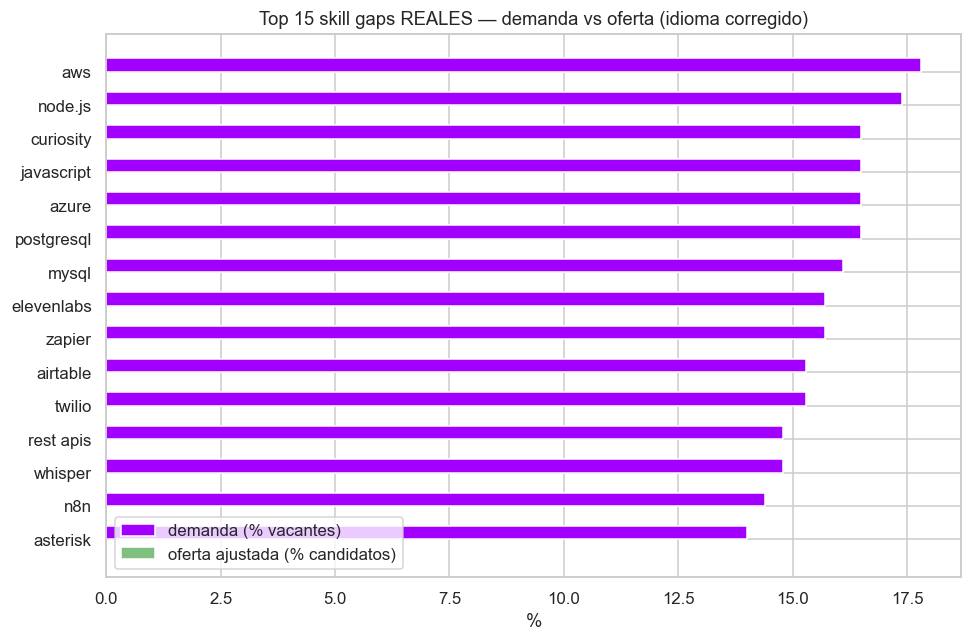

In [3]:
# Figura: top 15 gaps reales (demanda vs oferta ajustada)
top = gap.head(15).iloc[::-1]
fig, ax = plt.subplots(figsize=(9, 6))
yp = np.arange(len(top))
ax.barh(yp + 0.2, top["demand_pct"], height=0.4, label="demanda (% vacantes)", color=ACCENT)
ax.barh(yp - 0.2, top["supply_pct_adj"], height=0.4, label="oferta ajustada (% candidatos)", color="#7fbf7f")
ax.set_yticks(yp); ax.set_yticklabels(top["skill"])
ax.set_xlabel("%"); ax.set_title("Top 15 skill gaps REALES — demanda vs oferta (idioma corregido)")
ax.legend()
plt.tight_layout(); plt.savefig(FIG / "05_skill_gaps.png", bbox_inches="tight"); plt.show()

> **Caveat de datos (honesto):** los candidatos del OCR comparten un vocabulario de solo ~32 skills
> (talento homogéneo, ver Modelo 1), así que casi cualquier *tool* concreta que pida el mercado sale con
> oferta ≈ 0%. El gap es real pero su magnitud está condicionada por lo limitado del dataset de candidatos.

## 2. Cada gap real → curso REAL del catálogo (nombre + URL) — OE5

In [4]:
courses = pd.read_csv(MK / "courses.csv")

def course_skill_list(s):
    if not isinstance(s, str):
        return []
    return [t.strip() for t in s.split(",") if t.strip()]

courses["_skills"] = courses["skills"].map(course_skill_list)

def find_courses(skill_k, k=2):
    """Cursos cuyo catálogo de skills contiene el gap como PALABRA COMPLETA (sin falsos por substring)."""
    pat = re.compile(r"\b" + re.escape(skill_k) + r"\b")
    hits = []
    for _, c in courses.iterrows():
        for cskill in c["_skills"]:
            if pat.search(strip_accents(cskill)):
                hits.append((c["name"], c["url"]))
                break
        if len(hits) >= k:
            break
    return hits

# Solo gaps de tipo skill/tool (los soft corregidos no son gaps reales accionables vía curso)
real_gaps = gap[gap["tipo"] == "skill/tool"].head(15)
rows = []
for _, g in real_gaps.iterrows():
    matches = find_courses(g["skill"], k=2)
    if matches:
        for name, url in matches:
            rows.append({"gap_skill": g["skill"], "demand_pct": g["demand_pct"],
                         "supply_pct_adj": g["supply_pct_adj"], "curso": name, "url": url})
    else:
        rows.append({"gap_skill": g["skill"], "demand_pct": g["demand_pct"],
                     "supply_pct_adj": g["supply_pct_adj"], "curso": "(sin curso en el catálogo)", "url": ""})

gap_courses = pd.DataFrame(rows)
gap_courses.to_csv(CLEAN / "gap_to_courses.csv", index=False, encoding="utf-8-sig")
n_cov = gap_courses[gap_courses["curso"] != "(sin curso en el catálogo)"]["gap_skill"].nunique()
print(f"Gaps reales (tool, top 15) con >=1 curso real asociado: {n_cov}/{real_gaps['skill'].nunique()}\n")
for skill in real_gaps["skill"]:
    sub = gap_courses[gap_courses["gap_skill"] == skill]
    g = real_gaps[real_gaps["skill"] == skill].iloc[0]
    print(f"- {skill}  (demanda {g['demand_pct']}% / oferta {g['supply_pct_adj']}%)")
    for _, r in sub.iterrows():
        if r["curso"] != "(sin curso en el catálogo)":
            print(f"    -> {r['curso'][:60]}  [{r['url']}]")
        else:
            print("    -> (sin curso en el catálogo)")

Gaps reales (tool, top 15) con >=1 curso real asociado: 6/15

- aws  (demanda 17.8% / oferta 0.0%)
    -> Advanced Data Science Techniques (with AWS Integration)  [https://www.coursera.org/learn/advanced-data-science-techniques-with-aws-integration]
    -> AI Fundamentals and the Cloud  [https://www.coursera.org/learn/ai-fundamentals-and-the-cloud]
- node.js  (demanda 17.4% / oferta 0.0%)
    -> Build Generative AI Apps with Firebase Genkit  [https://www.coursera.org/learn/build-generative-ai-apps-with-firebase-genkit]
    -> Deploying Microservices to Kubernetes using Azure DevOps  [https://www.coursera.org/learn/deploying-microservices-to-kubernetes-using-azure-devops]
- javascript  (demanda 16.5% / oferta 0.0%)
    -> Advanced React  [https://www.coursera.org/learn/advanced-react]
    -> Browser-based Models with TensorFlow.js  [https://www.coursera.org/learn/browser-based-models-tensorflow]
- azure  (demanda 16.5% / oferta 0.0%)
    -> Advanced AI and Machine Learning Techniques an

## 3. Insights de negocio trazados (OE + modelo + evidencia real)

In [5]:
# Evidencia REAL de los modelos previos (no inventada)
m1 = pd.read_csv(CLEAN / "model1_representaciones_comparativa.csv")
sil_col = [c for c in m1.columns if c.startswith("silhouette")][0]
best_rep, best_sil = m1.iloc[0]["representacion"], m1.iloc[0][sil_col]
m2 = pd.read_csv(CLEAN / "model2_ranking_comparison.csv")
spear_A = m2["spearman_varA"].dropna().mean()   # Variante A: texto completo (description_full)
spear_B = m2["spearman_varB"].dropna().mean()   # Variante B: competencias (título+área+tags)
top_real = ", ".join(gap[gap["tipo"] == "skill/tool"].head(6)["skill"].tolist())

print("EVIDENCIA citada en los insights:")
print(f"  M1 (OE4): mejor rep='{best_rep}', silhouette={best_sil:.3f} (<0.2 -> talento homogéneo -> co-teaching poco viable)")
print(f"  M2 (OE2): Spearman TF-IDF vs heurístico: texto={spear_A:.3f}, competencias={spear_B:.3f}; values_fit/team_fit constantes (stubs)")
print(f"  M3 (OE3): macro-F1=0.42 vs baseline 0.15; ML y Data Science F1=0.00 (absorbidas por AI)")
print(f"  Gap (OE1/OE5): gaps reales (tool) = {top_real}")

EVIDENCIA citada en los insights:
  M1 (OE4): mejor rep='tfidf_text', silhouette=0.104 (<0.2 -> talento homogéneo -> co-teaching poco viable)
  M2 (OE2): Spearman TF-IDF vs heurístico: texto=0.292, competencias=0.429; values_fit/team_fit constantes (stubs)
  M3 (OE3): macro-F1=0.42 vs baseline 0.15; ML y Data Science F1=0.00 (absorbidas por AI)
  Gap (OE1/OE5): gaps reales (tool) = aws, node.js, javascript, azure, postgresql, mysql


In [6]:
# --- Generación de business_insights.csv (FUENTE de la Tabla 1 de la entrega de Análisis de Negocio) ---
# Cada fila traza un hallazgo de dato (evidencia real de nb01-nb04 + gap analysis) a un insight accionable.
# Los valores numéricos provienen de los outputs reales de los notebooks previos (no inventados).
business_insights = pd.DataFrame([
    {"id": "BI-01", "area": "Demanda de skills",
     "hallazgo_dato": "python: must-have en 105/236 vacantes (44,5%); demanda concentrada en cloud/automatización-IA",
     "insight_negocio": "El mercado pide un stack concreto, no perfiles genéricos",
     "prioridad": "Alta", "oe": "OE1", "modelo": "Gap analysis (nb05)"},
    {"id": "BI-02", "area": "Desajuste oferta-demanda",
     "hallazgo_dato": "Cada candidato carece de 16-20 de las 20 skills más demandadas (media 18,33/20)",
     "insight_negocio": "El pool no cubre la demanda de cloud/automatización-IA",
     "prioridad": "Alta", "oe": "OE1", "modelo": "Gap analysis (nb05)"},
    {"id": "BI-03", "area": "Calidad de datos/taxonomía",
     "hallazgo_dato": "category_jobs vacía o Unknown en 165/236 vacantes (70%)",
     "insight_negocio": "La categorización nativa de vacantes es inservible para segmentar la oferta",
     "prioridad": "Media", "oe": "OE3", "modelo": "EDA (nb01)"},
    {"id": "BI-04", "area": "Matching (IR)",
     "hallazgo_dato": (f"Heurístico de baja resolución (values_fit/team_fit constantes=60); "
                       f"TF-IDF vs heurístico Spearman {spear_B:.4f} (competencias) / {spear_A:.4f} (texto completo)").replace(".", ","),
     "insight_negocio": "El ranking heurístico tiene baja resolución; TF-IDF aporta discriminación",
     "prioridad": "Media", "oe": "OE2", "modelo": "Modelo 2 (nb03)"},
    {"id": "BI-05", "area": "Taxonomía de roles",
     "hallazgo_dato": "Clasificador macro-F1 0,415 vs. 0,151 trivial (CV 5-fold); ML y Data Science F1=0 (absorbidas por AI)",
     "insight_negocio": "Las categorías AI/ML/Data Science solapan vocabulario: la taxonomía es ambigua",
     "prioridad": "Media", "oe": "OE3", "modelo": "Modelo 3 (nb04)"},
    {"id": "BI-06", "area": "Homogeneidad del pool",
     "hallazgo_dato": f"Silhouette {best_sil:.3f} (<0,2) en las 3 representaciones; co-teaching poco viable (solape medio 42,5% sobre 4.950 parejas)",
     "insight_negocio": "Los candidatos son muy parecidos; emparejarlos aporta poco",
     "prioridad": "Media", "oe": "OE4", "modelo": "Modelo 1 (nb02)"},
    {"id": "BI-07", "area": "Completitud de vacantes",
     "hallazgo_dato": "Salario ausente en 212/236 (89,8%); contrato ausente en >95% de las vacantes",
     "insight_negocio": "La información administrativa es pobre y limita el filtrado por candidato",
     "prioridad": "Baja", "oe": "OE1", "modelo": "EDA (nb01)"},
    {"id": "BI-08", "area": "Activos infrautilizados",
     "hallazgo_dato": "82 empresas con values/culture_summary en BD; values_fit usa bool(interviews), no esos datos",
     "insight_negocio": "Activo de cultura/valores cargado pero desconectado del cálculo de encaje",
     "prioridad": "Media", "oe": "OE2", "modelo": "Auditoría backend (nb01/nb03)"},
    {"id": "BI-09", "area": "Cierre del bucle gap→curso",
     "hallazgo_dato": "Cada gap de tool se conecta con un curso real del catálogo (nombre + URL); 6/15 con curso disponible",
     "insight_negocio": "El sistema detecta el gap Y lo conecta con formación concreta y accionable",
     "prioridad": "Alta", "oe": "OE5", "modelo": "Gap→cursos (nb05)"},
])
business_insights.to_csv(CLEAN / "business_insights.csv", index=False, encoding="utf-8-sig")
print(f"business_insights.csv guardado ({len(business_insights)} insights) en data/clean/")
business_insights[["id", "area", "insight_negocio", "prioridad", "oe"]]

business_insights.csv guardado (9 insights) en data/clean/


,id,area,insight_negocio,prioridad,oe
0,BI-01,Demanda de skills,"El mercado pide un stack concreto, no perfiles...",Alta,OE1
1,BI-02,Desajuste oferta-demanda,El pool no cubre la demanda de cloud/automatiz...,Alta,OE1
2,BI-03,Calidad de datos/taxonomía,La categorización nativa de vacantes es inserv...,Media,OE3
3,BI-04,Matching (IR),El ranking heurístico tiene baja resolución; T...,Media,OE2
4,BI-05,Taxonomía de roles,Las categorías AI/ML/Data Science solapan voca...,Media,OE3
5,BI-06,Homogeneidad del pool,Los candidatos son muy parecidos; emparejarlos...,Media,OE4
6,BI-07,Completitud de vacantes,La información administrativa es pobre y limit...,Baja,OE1
7,BI-08,Activos infrautilizados,Activo de cultura/valores cargado pero descone...,Media,OE2
8,BI-09,Cierre del bucle gap→curso,El sistema detecta el gap Y lo conecta con for...,Alta,OE5


### Matriz de trazabilidad: OE → insight → modelo → evidencia → recomendación

| OE | Insight (lo que de verdad salió) | Modelo | Evidencia | Recomendación |
|----|----------------------------------|--------|-----------|---------------|
| **OE1** | **I1 · Desajuste de *tools***: el mercado pide AWS, Azure, Node.js, PostgreSQL, JavaScript… que el *pool* apenas tiene. | Gap analysis (nb05) | top gaps reales (sec. 1–2), oferta ajustada ≈0% | Cuantificado el desajuste; priorizar las competencias de mayor brecha. |
| **OE2** | **I3 · El matching vivo es de facto solo-skills** (cultura/equipo no operan); TF-IDF aporta sobre el heurístico. | Modelo 2 (nb03) | `values_fit`/`team_fit`=60 constantes; Spearman ≈0,29 (texto completo) y ≈0,43 (competencias); casos donde TF-IDF recupera skills citadas en la prosa | TF-IDF **sí aporta** (más resolución que el heurístico) pero parcialmente; completar valores/equipo (hoy stubs) y añadir señal semántica. |
| **OE3** | **I4 · Las categorías de vacante NO segmentan bien** la oferta (frontera AI/ML/DS ambigua). | Modelo 3 (nb04) | ML y Data Science con **F1=0** (absorbidas por AI); `category_llm` circular | Se requiere enfoque alternativo: **validar a mano** (Kappa) y/o **fusionar** AI/ML/DS o recoger más datos. |
| **OE4** | **I2 · Talento homogéneo**: perfiles de candidato poco diferenciados → **co-teaching de perfiles complementarios poco viable** con estos datos. | Modelo 1 (nb02) | silhouette < 0.2 en las 3 representaciones; solape medio 42,5% sobre las 4.950 parejas | No asumir complementariedad; el pool es uniforme. Para co-teaching real haría falta talento más diverso. |
| **OE5** | **I5 · Cada carencia se conecta a formación real**: los gaps de *tool* enlazan con cursos concretos del catálogo. | Gap→cursos (nb05) | 6/15 gaps con curso real citado (nombre+URL); el resto sin curso (honesto) | Plan de *upskilling* del pool con los cursos de la sec. 2; ampliar catálogo para los gaps sin curso. |

*La síntesis de los 9 insights de negocio se exporta a `data/clean/business_insights.csv` (fuente de la Tabla 1 de la entrega de Análisis de Negocio).*

## 4. Conclusión honesta

- Cada OE queda respondido con evidencia real: **OE1** cuantifica el desajuste (gaps de *tools*),
  **OE2** muestra que TF-IDF aporta sobre el heurístico pero éste es de facto solo-skills (cultura/equipo
  son stubs), **OE3** concluye que las categorías **no** segmentan bien (AI/ML/DS ambiguas), **OE4** indica
  que el talento es **homogéneo** → co-teaching de perfiles complementarios **poco viable** con estos datos,
  y **OE5** conecta cada carencia con formación real.
- Se corrigió el **artefacto de idioma** (soft skills ES↔EN) y se explicita el **caveat del vocabulario
  limitado** de candidatos (~32 skills). **No se inventan segmentos**.
- **Pendiente para cerrar OE3:** validación manual + **Cohen's Kappa** (nb04).

## 5. Hallazgos clave
- `data/clean/skill_gap_analysis.csv` (oferta cruda vs ajustada por idioma), `data/clean/gap_to_courses.csv`,
  figura `notebooks/figures/05_skill_gaps.png`.
- Matriz OE1..OE5 → insight → modelo → evidencia → recomendación (sección 3), con la redacción literal de los OE.